In [1]:
# General imports
import os, re
from pathlib import Path

# Image library imports
from matplotlib import pyplot as plt
from IPython.display import display
import ipywidgets as widgets
from rich import print

# Data science imports
import geopandas as gpd
import lasio as ls
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

In [2]:
# Well Data directory.
well_data_dir: str = Path("../data/aer/well")

# Shape file location.
water_well_shp = well_data_dir / "WaterWell_HQ_LAS/Shapefile/WWLAS_CLC_HQ.shp"
print(water_well_shp)
coal_hole_shp = well_data_dir / "CoalHoles_HQ_LAS/ShapeFile/CoalHole_CLC_HQ.shp"
print(coal_hole_shp)

../data/aer/well/WaterWell_HQ_LAS/Shapefile/WWLAS_CLC_HQ.shp

../data/aer/well/CoalHoles_HQ_LAS/ShapeFile/CoalHole_CLC_HQ.shp

In [3]:
# .geometry attribute.
ww_gdf = gpd.read_file(water_well_shp).to_crs(epsg=26912)
ch_gdf = gpd.read_file(coal_hole_shp).to_crs(epsg=26912)

In [4]:
print(list(ww_gdf.columns))
# LAS file names, GICW-ID
# Long-NAD83, Lat_NAD83
# UTM83-Z, UTM83-E, UTM83-N
# 10TM83-E, 10TM83-N
# EL-DEM15-M
# DLS-Loc
# Curve type: Depth below, Reference, Resistivity, Gamma ray

[
    'LAS_FI_NAM',
    'GIC_W_ID',
    'LONG_NAD83',
    'LAT_NAD83',
    'UTM83_Z',
    'E_UTM83',
    'N_UTM83',
    'E_10TM83',
    'N_10TM83',
    'EL_DEM15_M',
    'DLS_LOC',
    'CURVE_TYPE',
    'SHORTNAME',
    'PUBLISHER',
    'SHORTNAME_',
    'geometry'
]

In [5]:
print(list(ch_gdf.columns))

[
    'Name',
    'Alias2',
    'Source_Id',
    'Project',
    'Litholog',
    'E_10TM83',
    'N_10TM83',
    'Supplement',
    'Spatial_Pr',
    'Logger',
    'Total_Dept',
    'Depth_Unit',
    'Depth_ref',
    'El_DR_OUOM',
    'El_DR_masl',
    'Glgy_done',
    'Litholog_l',
    'Hyperlink',
    'SP_Res',
    'Gam_Bulk',
    'SP',
    'Conduct',
    'Bulk',
    'Gamma',
    'Caliper',
    'El_AB100',
    'Name_1',
    'Raster_Typ',
    'geometry'
]

In [6]:
# Extract well names.
def pick_name(row, candidates):
    for col in candidates:
        if col in row.index and not pd.isna(row[col]):
            text = str(row[col]).strip()
            if text != "":
                return text
    return None


# Make a container for all well records.
well_records = []

# For Water well.
for _, row in ww_gdf.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    # Extract well name defined with priority: LAS_FI_NAM > Name > SHORTNAME from a given row.
    name = pick_name(row, ["LAS_FI_NAM", "SHORTNAME"])
    if name is None:
        continue
    well_records.append(
        {
            "well_type": "WaterWell",
            "well_name": name,
            "well_id": pick_name(row, ["GIC_W_ID", "GIC_WELL_I"]),
            "x": float(row.geometry.x),
            "y": float(row.geometry.y),
        }
    )

# For Coal hole.
for _, row in ch_gdf.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    name = pick_name(row, ["Name", "Name_1"])
    if name is None:
        continue
    well_records.append(
        {
            "well_type": "CoalHole",
            "well_name": name,
            "well_id": pick_name(row, ["Source_Id"]),
            "x": float(row.geometry.x),
            "y": float(row.geometry.y),
        }
    )
well_df = pd.DataFrame(well_records)

In [7]:
well_df

,well_type,well_name,well_id,x,y
0,WaterWell,153840-a,153840.0,307835.034573,5.563906e+06
1,WaterWell,153842-a,153842.0,307865.241639,5.563872e+06
2,WaterWell,153926-a,153926.0,389121.199688,5.674698e+06
3,WaterWell,153843-a,153843.0,393054.360097,5.563842e+06
4,WaterWell,153844-a,153844.0,393724.628345,5.559780e+06
...,...,...,...,...,...
72,CoalHole,TH77-76,55.0,411112.686984,5.580320e+06
73,CoalHole,TH78-76,55.0,401396.586685,5.583678e+06
74,CoalHole,TH79-76,55.0,420839.482599,5.577134e+06
75,CoalHole,TH9-83,55.0,414546.097295,5.589883e+06


In [8]:
# Water well Table
water_lith_path = well_data_dir / "WaterWell_HQ_LAS/Tables/WWLAS_CLC_HQ_lithology.DBF"
water_collar_path = well_data_dir / "WaterWell_HQ_LAS/Tables/WWLAS_CLC_HQ_collar.dbf"

## Collar data: XYZ, TD
water_collar_df = gpd.read_file(water_collar_path)
print(water_collar_df.columns)
## Lithology data: litho type, name, depth top, depth bottom, material1, material2, colour
water_lith_df = gpd.read_file(water_lith_path)
print(water_lith_df.columns)

### "GIC_W_ID" & "CIC_W_I" are the same. I guess this is a kind of bore hole name. (Geological information center well ID)

Index(['LAS_FI_NAM', 'GIC_W_ID', 'LONG_NAD83', 'LAT_NAD83', 'UTM83_Z',
       'E_UTM83', 'N_UTM83', 'E_10TM83', 'N_10TM83', 'EL_DEM15_M', 'DLS_LOC',
       'CURVE_TYPE', 'SHORTNAME', 'PUBLISHER', 'SHORTNAME_'],
      dtype='str')

Index(['GIC_WELL_I', 'WELL_REPOR', 'FINALFROM', 'FINALTO', 'WATER_BEAR',
       'COLOUR', 'DESCRIPTIO', 'MATERIAL', 'FINALFROM_', 'FINALTO_M'],
      dtype='str')

In [9]:
# Coal hole Table

coal_lith_path = well_data_dir / "CoalHoles_HQ_LAS/Tables/CoalHole_CLC_HQ_Lithology.txt"
coal_collar_path = well_data_dir / "CoalHoles_HQ_LAS/Tables/CoalHole_CLC_HQ_Collar.dbf"

## Collar data: XYZ, TD
coal_collar_df = gpd.read_file(coal_collar_path)
print(coal_collar_df.columns)

coal_lith_name = [
    "Name",
    "Source_Id",
    "top_ft",
    "bottom_ft",
    "feet",
    "top_m",
    "bottom_m",
    "tom_m_dup",
    "bottom_m_dup",
    "litho",
    "litho_2",
    "colour",
    "description",
    "dummy",
]

coal_lith_df = pd.read_csv(coal_lith_path, names=coal_lith_name)
print(coal_lith_df.columns)

Index(['Name', 'Alias2', 'Source_Id', 'Project', 'Litholog', 'E_10TM83',
       'N_10TM83', 'Supplement', 'Spatial_Pr', 'Logger', 'Total_Dept',
       'Depth_Unit', 'El_DR_OUOM', 'El_DR_masl', 'Glgy_done', 'Litholog_l',
       'Hyperlink', 'SP_Res', 'Gam_Bulk', 'SP', 'Conduct', 'Bulk', 'Gamma',
       'Caliper', 'El_AB100', 'Name_1', 'Raster_Typ'],
      dtype='str')

Index(['Name', 'Source_Id', 'top_ft', 'bottom_ft', 'feet', 'top_m', 'bottom_m',
       'tom_m_dup', 'bottom_m_dup', 'litho', 'litho_2', 'colour',
       'description', 'dummy'],
      dtype='str')

In [10]:
lithology_columns = ["name", "top_m", "bottom_m", "litho", "colour"]

In [11]:
LITHO_SG = {
    'bentonitic/sand':"sg",
    'bentonitic/sandstone':"sg",
    'carbonaceous/sandstone':"sg",
    'chert/sandstone':"sg",
    'clay/gravel':"sg",
    'clay/sand':"sg",
    'clayey/sandstone':"sg",
    'coal/gravel':"sg",
    'coal/sandstone':"sg",
    'gravel':"sg",
    'gravel/sand':"sg",
    'gravel/sandstone':"sg",
    'pebbles/gravel':"sg",
    'sand':"sg",
    'sand/coal':"sg",
    'sand/shale':"sg",
    'sand/siltstone':"sg",
    'sand/till':"sg",
    'sandstone':"sg",
    'sandstone/ledges':"sg",
    'sandstone/shale':"sg",
    'sandstone/siltstone':"sg",
    'sandy/clay':"sg",
    'sandy/shale':"sg",
    'sandy/till':"sg",
    'shaly/sandstone':"sg",
    'silt/gravel':"sg",
    'silty/sandstone':"sg",
    'till/gravel':"sg"
}
LITHO_CLAY = {
    "clay":"clay",
    "clay/gravel":"clay",
    "clay/rocks":"clay",
    "clay/sand":"clay",
    "clay/shale":"clay",
    "clay/siltstone":"clay",
    "clay/till":"clay",
    "sandy/clay":"clay",
    "silty/clay":"clay",
    "till/clay":"clay",
}

ELSE_CASE = {
    "no recovery":"no recovery",
    "see comments":"no recovery",
    "no data":"no recovery",
    "old well":"no recovery",
    "unknown":"no recovery",
    "nan":"no recovery"
}


In [12]:
# SEARCH_COND = re.compile(r"(\w+)*(?:\s+|\sof\s|\s&\s|,\s)(\w+)$")
SEARCH_COND1 = re.compile(r"(\w+)(?:\s+|\sof\s|\s&\s)(\w+)$")
SEARCH_COND2 = re.compile(r"^(?:\w+\s)(\w+)(?:,\s\w+\s)(\w+)$")
SEARCH_COND3 = re.compile(r"^(\w+)$")


def extract_last_litho(litho_string) -> str:
    text = str(litho_string).lower().strip()
    exception_text = text.replace("/", " ")

    if text in ELSE_CASE or exception_text in {
        "no recovery",
        "see comments",
        "no data",
        "old well",
    }:
        return "no recovery"

    # Handle already-normalized and single-word lithology values.
    if text in {"sg", "clay", "mixed"}:
        return text
    if text in LITHO_SG:
        return LITHO_SG[text]
    if text in LITHO_CLAY:
        return LITHO_CLAY[text]

    match3 = SEARCH_COND3.search(text)
    if match3 and match3.group(1):
        text_ = match3.group(1)
        if text_ in LITHO_SG:
            return LITHO_SG[text_]
        if text_ in LITHO_CLAY:
            return LITHO_CLAY[text_]
        return "others"

    match2 = SEARCH_COND2.search(text)
    if match2 and match2.group(1) and match2.group(2):
        text_mod1 = match2.group(1) + "/" + match2.group(2)
        text_mod2 = match2.group(2) + "/" + match2.group(1)
        if text_mod1 in LITHO_SG:
            return LITHO_SG[text_mod1]
        if text_mod2 in LITHO_SG:
            return LITHO_SG[text_mod2]
        if text_mod1 in LITHO_CLAY:
            return LITHO_CLAY[text_mod1]
        if text_mod2 in LITHO_CLAY:
            return LITHO_CLAY[text_mod2]
        return "others"

    match1 = SEARCH_COND1.search(text)
    if match1 and match1.group(1) and match1.group(2):
        text_mod1 = match1.group(1) + "/" + match1.group(2)
        text_mod2 = match1.group(2) + "/" + match1.group(1)
        if text_mod1 in LITHO_SG:
            return LITHO_SG[text_mod1]
        if text_mod2 in LITHO_SG:
            return LITHO_SG[text_mod2]
        if text_mod1 in LITHO_CLAY:
            return LITHO_CLAY[text_mod1]
        if text_mod2 in LITHO_CLAY:
            return LITHO_CLAY[text_mod2]
        return "others"

    # Unknown single-word or unrecognized descriptions are grouped as mixed.
    return "others"


test = [
    extract_last_litho(litho)
    for litho in [
        "clay & sand",
        "sand till, sandy clay",
        "silt clay",
        "carbo silt clay",
        "no recovery",
        "see comments",
        "shale",
        "sand",
    ]
]
print(test)

['sg', 'clay', 'others', 'others', 'no recovery', 'no recovery', 'others', 'sg']

In [13]:
def allocate_color(litho_string) -> str:
    """
    Extract the last lithology term from a lithology string.
    """
    litho_string = litho_string.lower()
    if litho_string == "sg":
        out = "yellow"
    elif litho_string == "clay":
        out = "blue"
    elif litho_string == "others":
        out = "cyan"
    else:
        out = "none"
    return out


print(allocate_color("clay"))

blue

In [14]:
print(coal_collar_df["Name_1"].unique())

<StringArray>
[ '469692', 'TH10-83', 'TH11-83', 'TH12-83', 'TH13-83', 'TH14-83', 'TH15-83',
 'TH17-83', 'TH18-83', 'TH24-76', 'TH24-83', 'TH25-76', 'TH26-76', 'TH27-76',
 'TH28-76', 'TH29-76', 'TH30-76', 'TH31-76', 'TH32-76', 'TH33-76', 'TH34-76',
 'TH35-76', 'TH36-76', 'TH37-76', 'TH38-76', 'TH40-76', 'TH41-76', 'TH43-76',
 'TH44-76', 'TH45-76', 'TH47-76', 'TH48-76', 'TH53-76', 'TH54-76', 'TH55-76',
 'TH56-76', 'TH57-76', 'TH60-76', 'TH62-76', 'TH63-76', 'TH64-76', 'TH66-76',
 'TH73-76', 'TH74-76', 'TH75-76', 'TH76-76', 'TH77-76', 'TH78-76', 'TH79-76',
  'TH9-83', 'TH99-75']
Length: 51, dtype: str

In [15]:
print("Coal")
print(coal_collar_df.columns)
print(coal_lith_df.columns)
print("Water")
print(water_collar_df.columns)
print(water_lith_df.columns)

Coal

Index(['Name', 'Alias2', 'Source_Id', 'Project', 'Litholog', 'E_10TM83',
       'N_10TM83', 'Supplement', 'Spatial_Pr', 'Logger', 'Total_Dept',
       'Depth_Unit', 'El_DR_OUOM', 'El_DR_masl', 'Glgy_done', 'Litholog_l',
       'Hyperlink', 'SP_Res', 'Gam_Bulk', 'SP', 'Conduct', 'Bulk', 'Gamma',
       'Caliper', 'El_AB100', 'Name_1', 'Raster_Typ'],
      dtype='str')

Index(['Name', 'Source_Id', 'top_ft', 'bottom_ft', 'feet', 'top_m', 'bottom_m',
       'tom_m_dup', 'bottom_m_dup', 'litho', 'litho_2', 'colour',
       'description', 'dummy'],
      dtype='str')

Water

Index(['LAS_FI_NAM', 'GIC_W_ID', 'LONG_NAD83', 'LAT_NAD83', 'UTM83_Z',
       'E_UTM83', 'N_UTM83', 'E_10TM83', 'N_10TM83', 'EL_DEM15_M', 'DLS_LOC',
       'CURVE_TYPE', 'SHORTNAME', 'PUBLISHER', 'SHORTNAME_'],
      dtype='str')

Index(['GIC_WELL_I', 'WELL_REPOR', 'FINALFROM', 'FINALTO', 'WATER_BEAR',
       'COLOUR', 'DESCRIPTIO', 'MATERIAL', 'FINALFROM_', 'FINALTO_M'],
      dtype='str')

In [16]:
# water_lith_df, coal_lith_df change the column names to match lithology_columns
water_lith_df = water_lith_df.rename(
    columns={
        "GIC_WELL_I": "name",
        "FINALFROM": "top_m",
        "FINALTO": "bottom_m",
        "MATERIAL": "litho",
        "COLOUR": "colour",
    }
)
coal_lith_df = coal_lith_df.rename(
    columns={
        "Name": "name",
        "top_m": "top_m",
        "bot_m": "bottom_m",
        "litho_1": "litho",
        "colour": "colour",
    }
)

In [17]:
test = np.unique(
    np.asarray(
        list(water_lith_df["litho"].unique())
        + list(coal_lith_df["litho"].unique())
        + list(coal_lith_df["litho_2"].unique())
    )
)

abc = re.compile(SEARCH_COND1)
litho_lll = []

for i in range(len(test)):
    t = abc.match(test[i].lower())
    if t:
        t1 = t.group(1) + "/" + t.group(2)
        t2 = t.group(2) + "/" + t.group(1)
        if t1 in litho_lll or t2 in litho_lll or t1 in ELSE_CASE:
            continue
        else:
            litho_lll.append(t1)
            
abc = re.compile(SEARCH_COND2)
litho_lll2 = []

for i in range(len(test)):
    t = abc.match(test[i].lower())
    if t:
        t1 = t.group(1) + "/" + t.group(2)
        t2 = t.group(2) + "/" + t.group(1)
        if t1 in litho_lll2 or t2 in litho_lll2 or t1 in ELSE_CASE:
            continue
        else:
            litho_lll2.append(t1)

abc = re.compile(SEARCH_COND3)
litho_lll3 = []

for i in range(len(test)):
    t = abc.match(test[i].lower())
    if t:
        t1 = t.group(1)
        if t1 in litho_lll3 or t1 in ELSE_CASE:
            continue
        else:
            litho_lll3.append(t1)

print(pd.DataFrame(litho_lll+litho_lll2+litho_lll3, columns=["Lithology"]))
print(len(litho_lll+litho_lll2+litho_lll3))

Lithology
0              clay/gravel
1               clay/rocks
2                clay/sand
3            kelly/bushing
4                 old/well
5                sand/coal
6              sand/gravel
7             see/comments
8               shale/coal
9          shale/sandstone
10         shale/siltstone
11          siltstone/coal
12               till/clay
13             till/gravel
14              till/rocks
15         bentonitic/clay
16         bentonitic/sand
17    bentonitic/sandstone
18        bentonitic/shale
19    bentonitic/siltstone
20  carbonaceous/sandstone
21      carbonaceous/shale
22  carbonaceous/siltstone
23     carboniferous/shale
24        clayey/sandstone
25                 no/data
26             no/recovery
27              oyster/bed
28              sandy/clay
29             sandy/shale
30         sandy/siltstone
31              sandy/till
32         shaly/sandstone
33         shaly/siltstone
34              silty/clay
35         silty/sandstone
36             silty/shale
37              silty/till
38            trace/fossil
39         shale/sandstone
40             shale/shale
41               till/clay
42               bentonite
43                boulders
44                    clay
45                    coal
46                   drift
47                  gravel
48               ironstone
49                    sand
50               sandstone
51                   shale
52                    silt
53               siltstone
54                    till
55                 topsoil
56                   chert
57                 pebbles
58                    soil

59

In [18]:
test_clay = re.compile(r".*clay.")

for litho in litho_lll:
    a = test_clay.search(litho)
    if a:
        print(f"{litho}")


clay/gravel

clay/rocks

clay/sand

clayey/sandstone

In [19]:
litho_list = []
for i in test:
    litho_list.append(extract_last_litho(i))
litho_list = np.unique(litho_list)
class_table = pd.DataFrame(litho_list, columns=["Lithology"])

In [20]:
# Adjective/Component
# Primary Component/ Secondary Component
print(class_table)

Lithology
0         clay
1  no recovery
2       others
3           sg

In [21]:
class_table["Color"] = class_table["Lithology"].apply(allocate_color)

In [22]:
wl_df = water_lith_df.copy()[lithology_columns]
cl_df = coal_lith_df.copy()[lithology_columns]

In [23]:
wl_df["litho"] = wl_df["litho"].apply(extract_last_litho)
cl_df["litho"] = cl_df["litho"].apply(extract_last_litho)

In [24]:
water_items = []
for path in wl_df["name"].unique():
    las_file = well_data_dir / f"WaterWell_HQ_LAS/LAS_Files/{int(path)}-a.las"
    if not las_file.exists():
        print(f"LAS file not found: {las_file}")
        continue
    las = ls.read(las_file)
    col_name = las.df().columns
    water_items.extend(list(col_name))

water_items = list(set(water_items))

In [25]:
coal_items = []
for path in cl_df["name"].unique():
    las_file = well_data_dir / f"CoalHoles_HQ_LAS/LAS_Files/Litholog_{(path)}.las"
    if las_file.exists():
        col_name = ls.read(las_file).df().columns
        coal_items.extend(list(col_name))
    else:
        las_file_A = (
            well_data_dir / f"CoalHoles_HQ_LAS/LAS_Files/Litholog_{(path)}_A.las"
        )
        las_file_B = (
            well_data_dir / f"CoalHoles_HQ_LAS/LAS_Files/Litholog_{(path)}_B.las"
        )
        col_name = (
            ls.read(las_file_A, index_unit="m")
            .df()
            .join(ls.read(las_file_B, index_unit="m").df(), how="outer")
            .columns
        )
        coal_items.extend(list(col_name))
coal_items = list(set(coal_items))

Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}


In [26]:
print(water_items)
print(coal_items)

['GR', 'RES', 'RES2', 'RES3', 'RES1']

['GR', 'BDEN', 'RES', 'IND', 'SP', 'SFR', 'DC', 'CILD', 'CAL']

In [27]:
list_res = ["RES", "RES1", "RES2", "RES3", "CILD"]

In [28]:
def load_well_las(well_name: str, well_type: str):
    if well_type == "WaterWell":
        las_path = well_data_dir / f"WaterWell_HQ_LAS/LAS_Files/{well_name}.las"
        las_path = [las_path]
    else:
        tmp = well_data_dir / "CoalHoles_HQ_LAS/LAS_Files/"
        las_path = [
            tmp / f"Litholog_{well_name}.las",
            tmp / f"Litholog_{well_name}_A.las",
            tmp / f"Litholog_{well_name}_B.las",
        ]

    existing_paths = [path for path in las_path if path.exists()]
    if not existing_paths:
        return None, None

    df = []
    for path in existing_paths:
        las = ls.read(path)
        df_las = las.df()
        depth = np.asarray(df_las.index.values, dtype=float)
        units = las.curves[0].unit  # Depth unit
        has_units = units is not None
        has_ft = units.lower() in ["ft", "feet"]
        if has_units * has_ft:
            depth = depth * 0.3048  # Convert feet to meters
        df_las.index = depth
        df.append(df_las)

    combined_las = pd.concat(df).sort_index()
    depth = np.asarray(combined_las.index.values, dtype=float)

    res = None
    for col in list_res:
        if col in combined_las.columns:
            values = pd.to_numeric(combined_las[col], errors="coerce").to_numpy(
                dtype=float
            )
            if col == "CILD":
                values = 1000.0 / (values + 1e-6)
            res = values
            break

    if res is None:
        return None, None

    mask = (
        np.isfinite(depth) & np.isfinite(res) & (depth >= 0) & (res > 0) & (res < 1e3)
    )

    return depth[mask], res[mask]


In [29]:
# ATEM inversion data
atem_data_dir: str = Path(
    "../outputs/merged_inversion_results/merged_iteration_14_resistivity_wide.csv"
)

atem_df = pd.read_csv(atem_data_dir)

for col in ["x_wgs84", "y_wgs84", "distance", "dtm", "bheight"]:
    if col in atem_df.columns:
        atem_df[col] = pd.to_numeric(
            atem_df[col], errors="coerce"
        )  # "coerce" set invalid values to NaN.
if "Line" in atem_df.columns:
    atem_df["Line"] = atem_df["Line"].astype(str)

rho_cols = [c for c in atem_df.columns if c.startswith("rho_") and c.endswith("m")]
if len(rho_cols) == 0:
    raise ValueError(
        "No resistivity columns found in CSV (expected rho_XX.XXm columns)"
    )


# Get depth values from column names with "regex".
def parse_depth_from_col(col_name):
    # (...) is a capturing group (create a groups).
    # [0-9]+ matches any digit from 0 to 9, one or more.
    # (?:...) is a non-capturing group (don't create a group).
    # \.[0-9]+ matches with . followed by one or more digits.
    # ()? makes the previous group optional (0 or 1 times).
    match = re.match(r"rho_([0-9]+(?:\.[0-9]+)?)m", col_name)
    return float(match.group(1)) if match else np.nan


depth_values = np.array([parse_depth_from_col(c) for c in rho_cols], dtype=float)
resis_values = atem_df[rho_cols].to_numpy(dtype=float)

In [30]:
xy = atem_df[["x_wgs84", "y_wgs84"]].to_numpy(dtype=float)
xy_valid_maks = np.isfinite(xy).all(axis=1)
valid_atem_df = atem_df.loc[xy_valid_maks].reset_index(drop=True)
xy_valid = valid_atem_df[["x_wgs84", "y_wgs84"]].to_numpy(dtype=float)

# Build a KDTree model
model_tree = cKDTree(xy_valid)

In [31]:
# Interpolation parameters.
k_nearst_points: int = 100  # Select the number of nearest points for interpolation.
max_distance: float = 1000.0  # Maximum distance for interpolation (in meters).
idw_power: float = 0.0  # Inverse Distance Weighting.
map_dx = 100.0  # Grid spacing (X)
map_dy = 100.0  # Grid spacing (Y)
x_pad = 1000.0  # Padding for X axis (in meters)
y_pad = 1000.0  # Padding for Y axis (in meters)

# Create a grid for interpolation.
xmin = np.nanmin(xy_valid[:, 0]) - x_pad  # Minimum X value minus padding
ymin = np.nanmin(xy_valid[:, 1]) - y_pad  # Minimum Y value minus padding
xmax = np.nanmax(xy_valid[:, 0]) + x_pad  # Maximum X value plus padding
ymax = np.nanmax(xy_valid[:, 1]) + y_pad  # Maximum Y value plus padding
nx = int(np.floor((xmax - xmin) / map_dx))  # Number of grid points in X direction
ny = int(np.floor((ymax - ymin) / map_dy))  # Number of grid points in Y direction
x_map = np.arange(nx) * map_dx + xmin
y_map = np.arange(ny) * map_dy + ymin
X_map, Y_map = np.meshgrid(x_map, y_map)

idw_epsilon = min(map_dx, map_dy)
k_idw = min(k_nearst_points, len(xy_valid))
distances_idw, indices_idw = model_tree.query(
    np.c_[X_map.ravel(), Y_map.ravel()], k=k_idw
)

idw_weights = 1.0 / (distances_idw + idw_epsilon) ** idw_power

nearest_distance, _ = model_tree.query(np.c_[X_map.ravel(), Y_map.ravel()], k=1)
mask_outside_data = nearest_distance > max_distance

In [32]:
def interpolate_to_map(values):
    values = np.asarray(values, dtype=float)
    values_grid = np.sum(idw_weights * values[indices_idw], axis=1) / np.sum(
        idw_weights, axis=1
    )
    values_grid[mask_outside_data] = np.nan
    return values_grid.reshape(X_map.shape)

In [33]:
wl_df["litho"]

0             clay
1             clay
2             clay
3           others
4           others
          ...     
371         others
372             sg
373         others
374         others
375    no recovery
Name: litho, Length: 376, dtype: str

In [34]:
wl_mod_litho = [extract_last_litho(i) for i in wl_df["litho"]]
cl_mod_litho = [extract_last_litho(i) for i in cl_df["litho"]]
wl_df["litho"] = wl_mod_litho
cl_df["litho"] = cl_mod_litho


In [35]:
wl_df["litho"]

0             clay
1             clay
2             clay
3           others
4           others
          ...     
371         others
372             sg
373         others
374         others
375    no recovery
Name: litho, Length: 376, dtype: str

In [36]:
wl_mod_colour = [allocate_color(i) for i in wl_df["litho"]]
cl_mod_colour = [allocate_color(i) for i in cl_df["litho"]]
wl_df["colour"] = wl_mod_colour
cl_df["colour"] = cl_mod_colour

In [37]:
well_df

,well_type,well_name,well_id,x,y
0,WaterWell,153840-a,153840.0,307835.034573,5.563906e+06
1,WaterWell,153842-a,153842.0,307865.241639,5.563872e+06
2,WaterWell,153926-a,153926.0,389121.199688,5.674698e+06
3,WaterWell,153843-a,153843.0,393054.360097,5.563842e+06
4,WaterWell,153844-a,153844.0,393724.628345,5.559780e+06
...,...,...,...,...,...
72,CoalHole,TH77-76,55.0,411112.686984,5.580320e+06
73,CoalHole,TH78-76,55.0,401396.586685,5.583678e+06
74,CoalHole,TH79-76,55.0,420839.482599,5.577134e+06
75,CoalHole,TH9-83,55.0,414546.097295,5.589883e+06


In [38]:
wl_df["name"].unique()

array([111800., 111858., 111913., 127193., 140577., 141016., 153840.,
       153842., 153843., 153844., 153845., 153847., 153926., 196999.,
       221569., 223290., 223349., 224835., 228146., 238206., 239476.])

In [39]:
depth_values

array([  1.  ,   3.17,   5.71,   8.68,  12.15,  16.22,  20.98,  26.55,
        33.06,  40.68,  49.59,  60.02,  72.23,  86.51, 103.21, 122.76,
       145.63, 172.38, 203.69, 240.32, 283.17, 329.38])

In [40]:
def nearest_resistivity_at_xy(x, y):
    """Return the nearest ATEM location and its resistivity profile."""
    query_xy = np.asarray([[float(x), float(y)]], dtype=float)
    distance, valid_index = model_tree.query(query_xy, k=1)
    valid_index = int(valid_index[0])
    distance = float(distance[0])
    model_row = valid_atem_df.iloc[valid_index]
    model_profile = resis_values[xy_valid_maks][valid_index].copy()
    return {
        "x_wgs84": float(model_row["x_wgs84"]),
        "y_wgs84": float(model_row["y_wgs84"]),
        "resistivity": model_profile,
    }


def plot_resistivity_map(depth_index: int, well_index: int):

    target = well_df.iloc[well_index]

    plt.figure(figsize=(20, 8))
    plt.subplot(1, 2, 1)
    plt.pcolormesh(
        X_map,
        Y_map,
        np.log10(interpolate_to_map(resis_values[:, depth_index])),
        cmap="jet",
        shading="auto",
        vmin=np.log10(8),
        vmax=np.log10(60),
        alpha=0.5,
    )
    plt.colorbar(label="Log10 Resistivity (Ohm-m)")
    plt.title(f"Resistivity Map at Depth: {depth_values[depth_index]:.2f} m")
    plt.xlabel("X Coordinate (m)")
    plt.ylabel("Y Coordinate (m)")
    plt.gca().set_aspect("equal")

    ww = well_df[well_df["well_type"] == "WaterWell"]
    ch = well_df[well_df["well_type"] == "CoalHole"]
    plt.scatter(ww["x"], ww["y"], c="magenta", s=50, label="Water Wells", marker="x")
    plt.scatter(ch["x"], ch["y"], c="black", s=50, label="Coal Holes", marker="o")
    plt.scatter(
        target["x"],
        target["y"],
        s=100,
        label="Selected Well",
        marker="o",
        facecolors="none",
        edgecolors="red",
        linewidths=2,
    )
    plt.legend(["Water Wells", "Coal Holes", "Selected Well"], loc="upper right")

    depth, resis = load_well_las(
        target["well_name"],
        target["well_type"],
    )
    x = nearest_resistivity_at_xy(target["x"], target["y"])

    if target["well_type"] == "WaterWell":
        mask = wl_df["name"] == float(target["well_id"])
        log_top = wl_df.loc[mask, "top_m"].to_numpy(dtype=float)
        log_bot = wl_df.loc[mask, "bottom_m"].to_numpy(dtype=float)
        log_colour = wl_df.loc[mask, "colour"].to_numpy(dtype=str)
    else:
        mask = cl_df["name"] == target["well_name"]
        log_top = cl_df.loc[mask, "top_m"].to_numpy(dtype=float)
        log_bot = cl_df.loc[mask, "bottom_m"].to_numpy(dtype=float)
        log_colour = cl_df.loc[mask, "colour"].to_numpy(dtype=str)

    plt.subplot(1, 2, 2)
    if depth is None or resis is None:
        plt.text(0.5, 0.5, "No resistivity data available", ha="center", va="center")
    else:
        plt.plot(resis, depth, c="k", lw=2)
    plt.plot(
        x["resistivity"],
        depth_values,
        mec="b",
        lw=2,
        marker="o",
        mew=2,
        markerfacecolor="coral",
    )
    plt.axhline(
        depth_values[depth_index],
        color="r",
        linestyle="--",
        label=f"Selected Depth: {depth_values[depth_index]:.2f} m",
    )
    for i in range(len(log_top)):
        plt.fill_betweenx(
            [log_top[i], log_bot[i]],
            1,
            1000,
            color=log_colour[i],
            alpha=0.5,
        )

    from matplotlib.patches import Patch

    lithology_colors = {
        "Clay": allocate_color("clay"),
        "Sandstone/Sand": allocate_color("sg"),
        "others": allocate_color("others"),
        "None": allocate_color("none"),
    }
    plt.legend(
        handles=[
            Patch(facecolor=color, alpha=0.5, label=f"{lithology}: {color}")
            for lithology, color in lithology_colors.items()
        ],
        title="Lithology colors",
        loc="upper right",
        fontsize=8,
    )

    plt.xlim(1, 1000)
    plt.ylim(-3, 350)
    plt.gca().invert_yaxis()
    plt.xlabel("Resistivity (Ohm-m)")
    plt.ylabel("Depth (m)")
    plt.xscale("log")
    plt.grid()

    plt.show()


depth_slider = widgets.SelectionSlider(
    options=[(f"{depth_values[i]:.2f} m", i) for i in range(len(depth_values))],
    value=0,
    description="Depth:",
)
well_slider = widgets.SelectionSlider(
    options=[(f"{well_df.iloc[i]['well_name']}", i) for i in range(len(well_df))],
    value=0,
    description="Well:",
)

display(
    widgets.VBox(
        [
            depth_slider,
            well_slider,
            widgets.interactive_output(
                plot_resistivity_map,
                {"depth_index": depth_slider, "well_index": well_slider},
            ),
        ]
    )
)

- Bootstraping

$$
\rho_{AEM} = (\sum^N_{i=1}{\frac{t_i}{t_{AEM}}\frac{1}{\rho_i}})^{-1}
$$


In [41]:
valid_atem_df["x_wgs84"]

0         349008.093283
1         349019.628799
2         349035.192090
3         349053.704550
4         349074.221279
              ...      
561470    436742.327273
561471    436790.250714
561472    436837.844418
561473    436885.198059
561474    436919.822578
Name: x_wgs84, Length: 561475, dtype: float64

In [42]:
def calculate_boundary(depth_center):
    depth_center = np.asarray(depth_center, dtype=float)
    if depth_center.ndim != 1 or len(depth_center) == 0:
        raise ValueError("depth_center must be a non-empty one-dimensional array.")
    if not np.all(np.isfinite(depth_center)) or np.any(np.diff(depth_center) <= 0):
        raise ValueError("depth_center must contain finite, strictly increasing values.")

    boundaries = np.empty(len(depth_center) + 1, dtype=float)
    boundaries[0] = 0.0
    boundaries[1:-1] = (depth_center[:-1] + depth_center[1:]) / 2.0
    boundaries[-1] = depth_center[-1] + (depth_center[-1] - boundaries[-2])
    return boundaries


def sync_atem_litho_layer(well_index):
    """Return lithology fractions through the last AEM layer covered by the log."""
    target = well_df.iloc[well_index]
    x = nearest_resistivity_at_xy(target["x"], target["y"])

    if target["well_type"] == "WaterWell":
        mask = wl_df["name"] == float(target["well_id"])
        log_data = wl_df.loc[mask]
    else:
        mask = cl_df["name"] == target["well_name"]
        log_data = cl_df.loc[mask]

    log_top = log_data["top_m"].to_numpy(dtype=float)
    log_bot = log_data["bottom_m"].to_numpy(dtype=float)
    log_litho = log_data["litho"].to_numpy(dtype=str)

    valid_logs = (
        np.isfinite(log_top)
        & np.isfinite(log_bot)
        & (log_bot > log_top)
    )
    log_top = log_top[valid_logs]
    log_bot = log_bot[valid_logs]
    log_litho = log_litho[valid_logs]

    bound_aem = np.asarray(calculate_boundary(depth_values), dtype=float)
    layer_top = bound_aem[:-1, None]
    layer_bot = bound_aem[1:, None]
    thickness_aem = np.diff(bound_aem)

    # Calculate each log interval's overlap with every AEM layer.
    overlap = np.maximum(
        0.0,
        np.minimum(layer_bot, log_bot[None, :])
        - np.maximum(layer_top, log_top[None, :]),
    )

    covered_layers = np.any(overlap > 0.0, axis=1)
    if not np.any(covered_layers):
        return np.empty((0, 3), dtype=float), np.empty((0,), dtype=float)

    last_layer = np.flatnonzero(covered_layers)[-1] + 1
    overlap = overlap[:last_layer]
    thickness_aem = thickness_aem[:last_layer]

    A = np.zeros((last_layer, 3), dtype=float)
    for column, lithology in enumerate(("sg", "clay", "others")):
        A[:, column] = overlap[:, log_litho == lithology].sum(axis=1)
    A /= thickness_aem[:, None]

    return A, 1/x["resistivity"][:last_layer]

def calculate_linear_equation(A, b):
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float).reshape(-1, 1)
    if (A).shape[0] != b.shape[0]:
        raise ValueError("The number of rows in A must match the number of elements in b.")
    plt.imshow(A.T@A, cmap='viridis', interpolation='nearest')
    plt.show()
    x_sol, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
    return x_sol

In [43]:
A_joint = []
b_joint = []

for idx in range(len(well_df)):
    A,b = sync_atem_litho_layer(idx)
    A_joint.append(A)
    b_joint.append(b)

In [44]:
A_all = np.vstack(A_joint)
b_all = np.concatenate(b_joint)

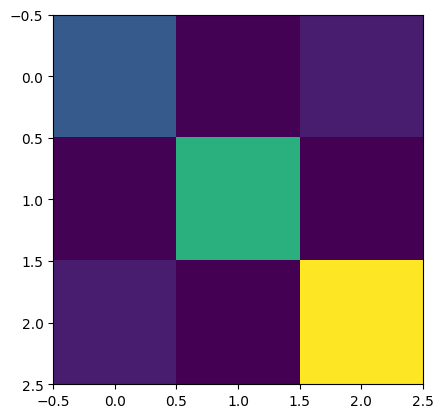

In [45]:
solution = calculate_linear_equation(A_all, b_all)

In [46]:
A_all.shape

(1186, 3)

In [47]:
def run_bootstrap_inversion(A_all, b_all, iterations=1000, n_equations=None):
    A_all = np.asarray(A_all, dtype=float)
    b_all = np.asarray(b_all, dtype=float).reshape(-1)
    if n_equations is None:
        n_equations, n_lithologies = A_all.shape
    else:
        n_lithologies = A_all.shape[1]

    if b_all.shape[0] != A_all.shape[0]:
        raise ValueError("A_all and b_all must contain the same number of equations.")

    bootstrap_conductivities = np.zeros((iterations, n_lithologies))

    for i in range(iterations):
        bootstrap_indices = np.random.choice(
            n_equations,
            size=n_equations,
            replace=True,
        )

        A_resampled = A_all[bootstrap_indices]
        b_resampled = b_all[bootstrap_indices]

        # Leaset-squares solution to a linear matrix equation.
        x_sol, _, _, _ = np.linalg.lstsq(A_resampled, b_resampled, rcond=None)
        bootstrap_conductivities[i, :] = x_sol

    # Convert conductivity to resistivity.
    bootstrap_resistivities = 1.0 / (bootstrap_conductivities + 1e-9)
    return bootstrap_resistivities

In [48]:
bootstrap_res = run_bootstrap_inversion(A_all, b_all, iterations=1000, n_equations = 500)
print(f"Maximum resistivity: {np.max(bootstrap_res):.2f} Ohm-m")
print(f"Minimum resistivity: {np.min(bootstrap_res):.2f} Ohm-m")

Maximum resistivity: 18.95 Ohm-m

Minimum resistivity: 10.60 Ohm-m

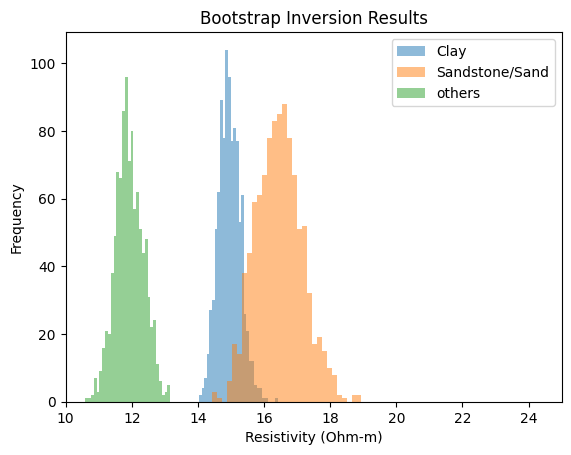

In [53]:
plt.hist(bootstrap_res[:, 1], bins=30, alpha=0.5, label='Clay')
plt.hist(bootstrap_res[:, 0], bins=30, alpha=0.5, label='Sandstone/Sand')
plt.hist(bootstrap_res[:, 2], bins=30, alpha=0.5, label='others')
plt.xlim(10, 25)
plt.xlabel('Resistivity (Ohm-m)')
plt.ylabel('Frequency')
plt.title('Bootstrap Inversion Results')
plt.legend()

In [50]:
# def calculate_aem_pixel_rho(depth:list, resistivity:list)->float:
#     if len(depth) != len(resistivity) + 1:
#         raise ValueError("Depth list mus have one more element including surface (z=0).")
#     depth = np.asarray(depth, dtype=float)
#     resistivity = np.asarray(resistivity, dtype=float)
#     thickness = np.diff(depth)
#     t_aem = np.sum(thickness)
#     rho_aem = np.sum(thickness/t_aem/resistivity)**(-1)
#     return rho_aem

# def sample_resistivitys_sets(well_index, n=75):
#     """Return the near ATEM locations and their resistivity profiles."""
#     target = well_df.iloc[well_index]
#     x = target["x"]
#     y = target["y"]
#     if target["well_type"] == "WaterWell":
#         mask = wl_df["name"] == float(target["well_id"])
#         log_top = wl_df.loc[mask, "top_m"].to_numpy(dtype=float)
#         log_bot = wl_df.loc[mask, "bottom_m"].to_numpy(dtype=float)
#         log_litho = wl_df.loc[mask, "litho"].to_numpy(dtype=str)
#     else:
#         mask = cl_df["name"] == target["well_name"]
#         log_top = cl_df.loc[mask, "top_m"].to_numpy(dtype=float)
#         log_bot = cl_df.loc[mask, "bottom_m"].to_numpy(dtype=float)
#         log_litho = cl_df.loc[mask, "litho"].to_numpy(dtype=str)
    
#     mask_clay = log_litho =="clay"
#     mask_sg = log_litho == "sg"
#     mask_mixed = log_litho == "mixed" 
#     t_clay = np.sum(log_bot[mask_clay] - log_top[mask_clay])
#     t_sg = np.sum(log_bot[mask_sg] - log_top[mask_sg])
#     t_mixed = np.sum(log_bot[mask_mixed] - log_top[mask_mixed])
#     t_amem = depth_values[-1]

#     query_xy = np.asarray([[float(x), float(y)]], dtype=float)
#     distances, valid_index = model_tree.query(query_xy, k=n)
#     model_rows = valid_atem_df.iloc[valid_index[0]]
#     model_profiles = resis_values[xy_valid_maks][valid_index[0]].copy()
#     print(f"Sampled averaged distnace: {np.mean(distances):.2f} m, max distance: {np.max(distances):.2f} m")
#     return {
#         "x_wgs84": (model_rows["x_wgs84"]),
#         "y_wgs84": (model_rows["y_wgs84"]),
#         "distances": distances,
#         "resistivity": model_profiles,
#         "t_clay": t_clay,
#         "t_sg": t_sg,
#         "t_mixed": t_mixed,
#         "t_aem": t_amem
#     }


In [51]:
# def generate_matrix_A(t_sg:float, t_mixed:float, t_clay:float, t_aem:float, n_sample:int):
#     A = np.zeros((n_sample, 3), dtype=float)
#     A[:,0] = t_sg/t_aem
#     A[:,1] = t_mixed/t_aem
#     A[:,2] = t_clay/t_aem
#     return A


Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}


Saved: ../outputs/well_analysis/well_lithology.csv (2967 rows)

Saved: ../outputs/well_analysis/well_logging_resistivity.csv (151436 rows)

Saved: ../outputs/well_analysis/well_atem_inversion.csv (1694 rows)

Wells without logging resistivity: 3

Loaded lithology CSV: (2967, 8)

Loaded logging CSV: (151436, 5)

Loaded ATEM CSV: (1694, 10)

Plot validation well index: 0

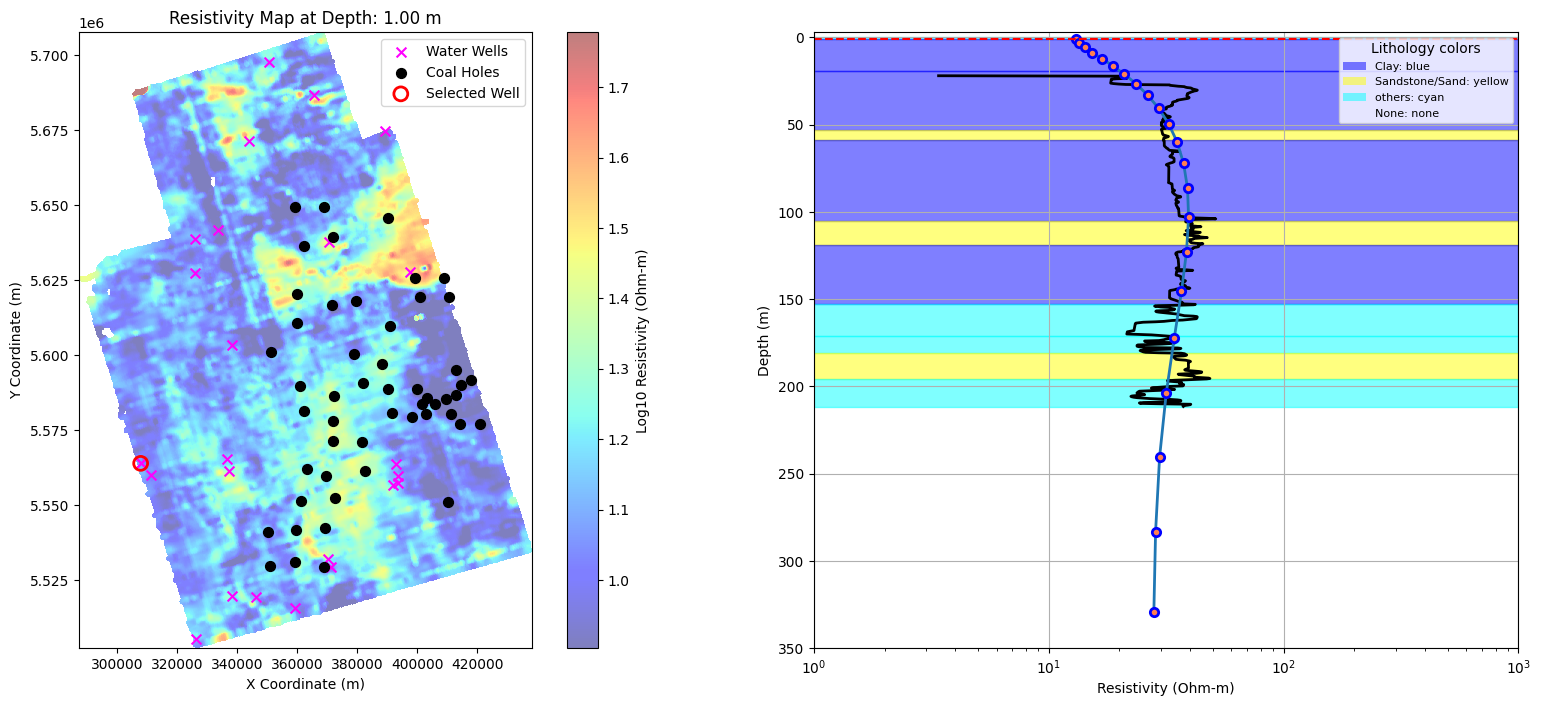

In [54]:
output_dir = Path("../outputs/well_analysis")
output_dir.mkdir(parents=True, exist_ok=True)

lithology_rows = []
logging_rows = []
logging_missing_wells = []
atem_rows = []

for _, well in well_df.iterrows():
    well_type = well["well_type"]
    well_id = well["well_id"]
    well_name = well["well_name"]

    if well_type == "WaterWell":
        lithology_mask = wl_df["name"] == float(well_id)
        well_log_id = well_id
        lithology_df = wl_df.loc[lithology_mask]
    else:
        lithology_mask = cl_df["name"] == well_name
        well_log_id = well_name
        lithology_df = cl_df.loc[lithology_mask]

    for _, lithology in lithology_df.iterrows():
        lithology_rows.append(
            {
                "well_id": well_id,
                "well_name": well_name,
                "well_type": well_type,
                "well_log_id": well_log_id,
                "top_m": lithology["top_m"],
                "bottom_m": lithology["bottom_m"],
                "lithology": lithology["litho"],
                "colour": lithology["colour"],
            }
        )

    depth, resis = load_well_las(well_name, well_type)
    if depth is None or resis is None:
        logging_missing_wells.append(
            {
                "well_id": well_id,
                "well_name": well_name,
                "well_type": well_type,
            }
        )
    else:
        for depth_m, resistivity in zip(depth, resis):
            logging_rows.append(
                {
                    "well_id": well_id,
                    "well_name": well_name,
                    "well_type": well_type,
                    "depth_m": depth_m,
                    "logging_resistivity_ohm_m": resistivity,
                }
            )

    query_xy = np.asarray([[float(well["x"]), float(well["y"])]], dtype=float)
    distance, valid_index = model_tree.query(query_xy, k=1)
    distance = float(distance[0])
    valid_index = int(valid_index[0])
    atem_record = valid_atem_df.iloc[valid_index]
    atem_profile = resis_values[xy_valid_maks][valid_index]

    for depth_m, resistivity in zip(depth_values, atem_profile):
        atem_rows.append(
            {
                "well_id": well_id,
                "well_name": well_name,
                "well_type": well_type,
                "well_x": well["x"],
                "well_y": well["y"],
                "atem_x": atem_record["x_wgs84"],
                "atem_y": atem_record["y_wgs84"],
                "atem_distance_m": distance,
                "depth_m": depth_m,
                "atem_resistivity_ohm_m": resistivity,
            }
        )

well_lithology_export_df = pd.DataFrame(lithology_rows)
well_logging_export_df = pd.DataFrame(logging_rows)
well_atem_export_df = pd.DataFrame(atem_rows)
logging_missing_df = pd.DataFrame(logging_missing_wells)

well_lithology_export_df.to_csv(output_dir / "well_lithology.csv", index=False)
well_logging_export_df.to_csv(output_dir / "well_logging_resistivity.csv", index=False)
well_atem_export_df.to_csv(output_dir / "well_atem_inversion.csv", index=False)

print(f"Saved: {output_dir / 'well_lithology.csv'} ({len(well_lithology_export_df)} rows)")
print(f"Saved: {output_dir / 'well_logging_resistivity.csv'} ({len(well_logging_export_df)} rows)")
print(f"Saved: {output_dir / 'well_atem_inversion.csv'} ({len(well_atem_export_df)} rows)")
print(f"Wells without logging resistivity: {len(logging_missing_df)}")

loaded_lithology_df = pd.read_csv(output_dir / "well_lithology.csv")
loaded_logging_df = pd.read_csv(output_dir / "well_logging_resistivity.csv")
loaded_atem_df = pd.read_csv(output_dir / "well_atem_inversion.csv")

assert {
    "well_id",
    "well_name",
    "well_type",
    "top_m",
    "bottom_m",
    "lithology",
}.issubset(loaded_lithology_df.columns)
assert {
    "well_id",
    "well_name",
    "well_type",
    "depth_m",
    "logging_resistivity_ohm_m",
}.issubset(loaded_logging_df.columns)
assert {
    "well_id",
    "well_name",
    "well_type",
    "depth_m",
    "atem_resistivity_ohm_m",
}.issubset(loaded_atem_df.columns)

print(f"Loaded lithology CSV: {loaded_lithology_df.shape}")
print(f"Loaded logging CSV: {loaded_logging_df.shape}")
print(f"Loaded ATEM CSV: {loaded_atem_df.shape}")

plot_well_index = None
for candidate_index, well in well_df.iterrows():
    if well["well_type"] == "WaterWell":
        colour_values = wl_df.loc[
            wl_df["name"] == float(well["well_id"]),
            "colour",
        ]
    else:
        colour_values = cl_df.loc[
            cl_df["name"] == well["well_name"],
            "colour",
        ]

    if len(colour_values) > 0 and colour_values.notna().all():
        plot_well_index = candidate_index
        break

if plot_well_index is None:
    raise ValueError("No well with valid lithology colours was found for plotting.")

print(f"Plot validation well index: {plot_well_index}")
plot_resistivity_map(depth_index=0, well_index=plot_well_index)